# **Project #3: Point Cloud Registration & SLAM Basics**

In [1]:
import numpy as np
import open3d as o3d
import os
import copy
import time
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# 1. Point Cloud Registration Using ICP

(a) Select Two Point Clouds:

In [2]:
def load_kitti_pointcloud(bin_path):
    scan = np.fromfile(bin_path, dtype=np.float32).reshape((-1, 4))
    points = scan[:, :3]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    return pcd

def preprocess_pointcloud(pcd, voxel_size):
    pcd_down = pcd.voxel_down_sample(voxel_size)

    radius_normal = voxel_size * 2
    pcd_down.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(
            radius=radius_normal,
            max_nn=30
        )
    )
    return pcd_down


data_dir = "kitti_sample/00"

frame_source_idx = 1
frame_target_idx = 0
voxel_size = 0.2

source_path = os.path.join(data_dir, f"{frame_source_idx:06d}.bin")
target_path = os.path.join(data_dir, f"{frame_target_idx:06d}.bin")

source_raw = load_kitti_pointcloud(source_path)
target_raw = load_kitti_pointcloud(target_path)

source = preprocess_pointcloud(source_raw, voxel_size)
target = preprocess_pointcloud(target_raw, voxel_size)

print(f"Source frame ({frame_source_idx}): {len(source.points)} points")
print(f"Target frame ({frame_target_idx}): {len(target.points)} points")

Source frame (1): 31465 points
Target frame (0): 31828 points


(b) Visualize Unregistered Point Clouds:

In [3]:
def visualize_unregistered(source, target):
    s = copy.deepcopy(source)
    t = copy.deepcopy(target)

    s.paint_uniform_color([1, 0, 0])
    t.paint_uniform_color([0, 0, 1])

    o3d.visualization.draw_geometries(
        [s, t],
        window_name="Unregistered Point Clouds",
        width=1024,
        height=768
    )

visualize_unregistered(source, target)

(c) Apply ICP Algorithm: 

In [4]:
def apply_icp(source, target, voxel_size, init=np.eye(4)):
    threshold = voxel_size * 1.5
    start = time.time()

    reg = o3d.pipelines.registration.registration_icp(
        source,
        target,
        threshold,
        init,
        o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=10000)
    )

    end = time.time()

    print("Transformation Matrix:\n", reg.transformation)
    print(f"Fitness: {reg.fitness:.4f}")
    print(f"Inlier RMSE: {reg.inlier_rmse:.4f}")
    print(f"Time: {end - start:.3f} sec\n")

    return reg

registration_result = apply_icp(source, target, voxel_size)

Transformation Matrix:
 [[ 9.99994937e-01 -3.11831873e-03 -6.34031741e-04  6.83747521e-01]
 [ 3.11712729e-03  9.99993390e-01 -1.87154581e-03  2.22298065e-03]
 [ 6.39863627e-04  1.86955998e-03  9.99998048e-01  8.31956424e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Fitness: 0.8699
Inlier RMSE: 0.1240
Time: 0.093 sec



(d) Visualize Aligned Point Clouds: 

In [5]:
def visualize_aligned(source, target, transformation):
    s = copy.deepcopy(source)
    t = copy.deepcopy(target)

    s.transform(transformation)

    s.paint_uniform_color([1, 0, 0])
    t.paint_uniform_color([0, 0, 1])

    o3d.visualization.draw_geometries(
        [s, t],
        window_name="Aligned Point Clouds",
        width=1024,
        height=768
    )

visualize_aligned(source, target, registration_result.transformation)

#  2. Incremental Registration of Multiple Point Clouds Using ICP

(a) Use the Result from Previous Part:

In [6]:
def incremental_mapping(data_dir, num_frames=142, voxel_size=0.2):
    poses = [np.eye(4)]
    transformations = []

    target_raw = load_kitti_pointcloud(os.path.join(data_dir, "000000.bin"))
    target = preprocess_pointcloud(target_raw, voxel_size)

    for i in range(1, num_frames):
        file_path = os.path.join(data_dir, f"{i:06d}.bin")
        if not os.path.exists(file_path):
            break

        source_raw = load_kitti_pointcloud(file_path)
        source = preprocess_pointcloud(source_raw, voxel_size)

        if len(transformations) > 0:
            init_guess = transformations[-1]
        else:
            init_guess = np.eye(4)

        print(f"\n[Registering Frame {i:03d}]")
        reg = apply_icp(source, target, voxel_size, init_guess)

        T = reg.transformation
        transformations.append(T)

        current_pose = poses[-1] @ T
        poses.append(current_pose)

        target = source

    print("\nIncremental Mapping Finished.")
    print(f"Total poses estimated: {len(poses)}")
    return poses

estimated_poses = incremental_mapping(data_dir, num_frames=142, voxel_size=0.2)


[Registering Frame 001]
Transformation Matrix:
 [[ 9.99994937e-01 -3.11831873e-03 -6.34031741e-04  6.83747521e-01]
 [ 3.11712729e-03  9.99993390e-01 -1.87154581e-03  2.22298065e-03]
 [ 6.39863627e-04  1.86955998e-03  9.99998048e-01  8.31956424e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Fitness: 0.8699
Inlier RMSE: 0.1240
Time: 0.114 sec


[Registering Frame 002]
Transformation Matrix:
 [[ 9.99992093e-01 -3.93886340e-03 -5.47356528e-04  6.98616058e-01]
 [ 3.93923662e-03  9.99992008e-01  6.82469790e-04  9.90720211e-03]
 [ 5.44663998e-04 -6.84620561e-04  9.99999617e-01 -1.55981832e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Fitness: 0.8504
Inlier RMSE: 0.1210
Time: 0.070 sec


[Registering Frame 003]
Transformation Matrix:
 [[ 9.99991949e-01 -3.98731106e-03 -4.51394360e-04  7.18745776e-01]
 [ 3.98751071e-03  9.99991952e-01  4.42248245e-04  6.93209784e-03]
 [ 4.49627346e-04 -4.44044624e-04  9.99999800e-01 -1.81272874e-03]
 [ 0.000

(b) Visualize the Final Map:

In [12]:
def build_final_map(data_dir, poses, voxel_size=0.2):
    final_map = o3d.geometry.PointCloud()
    
    for i, pose in enumerate(poses):
        file_path = os.path.join(data_dir, f"{i:06d}.bin")
        if not os.path.exists(file_path):
            continue

        pcd = load_kitti_pointcloud(file_path)
        pcd = pcd.voxel_down_sample(voxel_size)
        pcd.transform(pose)

        final_map += pcd

        if i % 20 == 0:
            print(f"Integrated frame {i}")

    final_map = final_map.voxel_down_sample(voxel_size)
    print(f"\nFinal map has {len(final_map.points)} points")

    points = np.asarray(final_map.points)
    z = points[:, 2]
    z_min, z_max = z.min(), z.max()

    if z_max > z_min:
        colors = np.zeros(points.shape)
        colors[:, 2] = (z - z_min) / (z_max - z_min)
        final_map.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries(
        [final_map],
        window_name="Final Unified 3D Map",
        width=1200,
        height=800
    )
    return final_map

final_map = build_final_map(data_dir, estimated_poses)

Integrated frame 0
Integrated frame 20
Integrated frame 40
Integrated frame 60
Integrated frame 80
Integrated frame 100
Integrated frame 120
Integrated frame 140

Final map has 440765 points


#  3. Path Evaluation Using FDE and ADE

(a) Visualize Paths: 

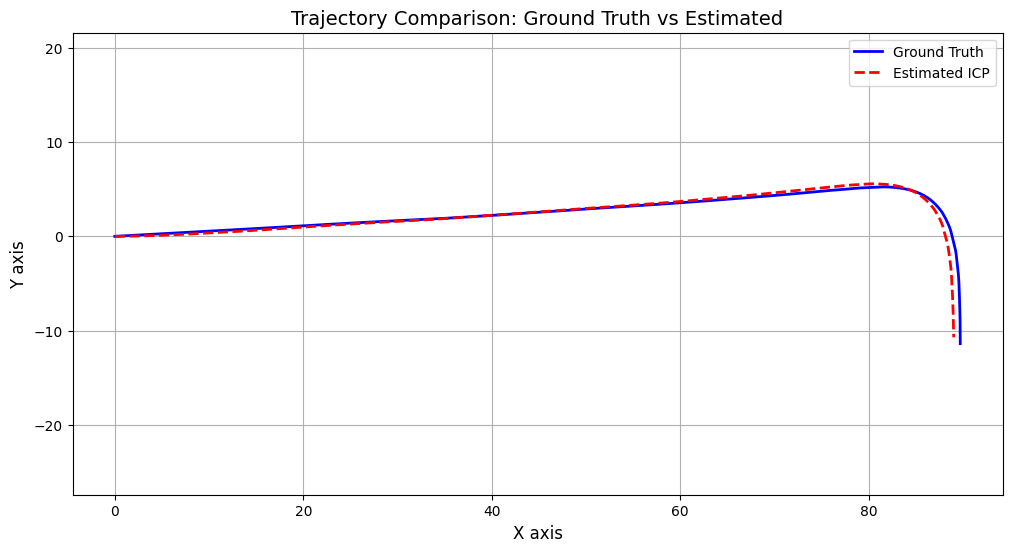

In [14]:
def visualize_trajectory(estimated_poses, gt_path):
    gt_data = np.loadtxt(gt_path)
    min_len = min(len(gt_data), len(estimated_poses))
    gt_data = gt_data[:min_len]
    estimated_poses = estimated_poses[:min_len]

    gt_x = gt_data[:, 3]
    gt_z = gt_data[:, 11]

    est_forward = np.array([pose[0, 3] for pose in estimated_poses])
    est_sideways = np.array([pose[1, 3] for pose in estimated_poses])

    plt.figure(figsize=(12, 6))
    plt.plot(gt_z, -gt_x, 'b-', label='Ground Truth', linewidth=2)
    plt.plot(est_forward, est_sideways, 'r--', label='Estimated ICP', linewidth=2)

    plt.title("Trajectory Comparison: Ground Truth vs Estimated", fontsize=14)
    plt.xlabel("X axis", fontsize=12)
    plt.ylabel("Y axis", fontsize=12)

    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

visualize_trajectory(estimated_poses, "kitti_sample/gt_pose_00.txt")

(b) Calculate Final Displacement Error (FDE): 

In [9]:
def compute_FDE(estimated_poses, gt_path):
    gt_data = np.loadtxt(gt_path)
    min_len = min(len(gt_data), len(estimated_poses))
    gt_data = gt_data[:min_len]
    estimated_poses = estimated_poses[:min_len]

    gt_x = gt_data[:, 3]
    gt_z = gt_data[:, 11]
    est_forward = np.array([pose[0, 3] for pose in estimated_poses])
    est_sideways = np.array([pose[1, 3] for pose in estimated_poses])

    gt_forward = gt_z
    gt_sideways = -gt_x
    est_final = np.array([est_forward[-1], est_sideways[-1]])
    gt_final = np.array([gt_forward[-1], gt_sideways[-1]])

    FDE = np.linalg.norm(est_final - gt_final)
    print(f"Final Displacement Error (FDE): {FDE:.4f} meters")

    return FDE

fde = compute_FDE(estimated_poses, "kitti_sample/gt_pose_00.txt")

Final Displacement Error (FDE): 0.9684 meters


(c) Calculate Average Displacement Error (ADE):

In [10]:
def compute_ADE(estimated_poses, gt_path):
    gt_data = np.loadtxt(gt_path)
    min_len = min(len(gt_data), len(estimated_poses))
    gt_data = gt_data[:min_len]
    estimated_poses = estimated_poses[:min_len]

    gt_x = gt_data[:, 3]
    gt_z = gt_data[:, 11]
    est_forward = np.array([pose[0, 3] for pose in estimated_poses])
    est_sideways = np.array([pose[1, 3] for pose in estimated_poses])

    gt_forward = gt_z
    gt_sideways = -gt_x
    est_traj = np.vstack((est_forward, est_sideways)).T
    gt_traj = np.vstack((gt_forward, gt_sideways)).T

    errors = np.linalg.norm(est_traj - gt_traj, axis=1)
    ADE = np.mean(errors)

    print(f"Average Displacement Error (ADE): {ADE:.4f} meters")
    return ADE

ade = compute_ADE(estimated_poses, "kitti_sample/gt_pose_00.txt")

Average Displacement Error (ADE): 1.1279 meters


(d) Analysis and Discussion: